# Main daily data EDA

This is a self-contained EDA notebook. It does not require SQLite, SQL, the Kalshi API, or the extraction pipeline to be running.

It works only with the CSV and JSON outputs created by `daily_data_diagnostic.ipynb`.

In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "data/demo/export_summary.json").exists()
    ),
    Path.cwd(),
)
# DATA_DIR = PROJECT_ROOT / "data" / "demo"
# To inspect the filtered view instead, use:
DATA_DIR = PROJECT_ROOT / "data" / "demo_filtered"

METADATA_PATH = DATA_DIR / "main_market_metadata.csv"
CANDLES_PATH = DATA_DIR / "main_daily_candles.csv.gz"
SUMMARY_PATH = DATA_DIR / "export_summary.json"

In [4]:
metadata_text_columns = [
    "market_id", "market_ticker", "event_ticker", "series_ticker",
    "market_question", "market_subtitle", "yes_subtitle", "no_subtitle",
    "market_rules", "event_question", "event_subtitle", "series_title",
    "series_category", "series_frequency", "market_status",
    "market_result", "download_status",
]
metadata = pd.read_csv(
    METADATA_PATH,
    dtype={column: "string" for column in metadata_text_columns},
)


for column in [
    "history_start_ts", "history_end_ts",
    "first_observation_ts", "last_observation_ts",
]:
    metadata[column] = pd.to_datetime(
        pd.to_numeric(metadata[column], errors="coerce"),
        unit="s",
        utc=True,
        errors="coerce",
    )

for column in [
    "passes_volume_filter", "passes_lifetime_filter", "passes_both_filters",
    "volume_fp", "lifetime_days", "expected_daily_rows",
    "received_daily_rows", "actual_candles_exported",
]:
    metadata[column] = pd.to_numeric(metadata[column], errors="coerce")
metadata.sample(5)


,market_id,market_ticker,event_ticker,series_ticker,market_question,market_subtitle,yes_subtitle,no_subtitle,market_rules,event_question,event_subtitle,series_title,series_category,series_frequency,market_status,market_result,open_time,close_time,passes_volume_filter,passes_lifetime_filter,passes_both_filters,volume_fp,lifetime_days,history_start_ts,history_end_ts,expected_daily_rows,received_daily_rows,first_observation_ts,last_observation_ts,download_status,actual_candles_exported
1577,kalshi:KXEARNINGSMENTIONKLAR-26AUG18-WALM,KXEARNINGSMENTIONKLAR-26AUG18-WALM,KXEARNINGSMENTIONKLAR-26AUG18,KXEARNINGSMENTIONKLAR,What will Klarna Group plc say during their next earnings call?,<NA>,Walmart,Walmart,If Walmart is said by any Klarna Group plc representative (including the operator of the call) during the next Klarn...,What will Klarna say during their next earnings call?,"On Aug 18, 2026",Klarna Earnings Call,Mentions,one_off,finalized,yes,2026-07-23T18:51:00Z,2026-08-18T14:23:56Z,1,1,1,13366.22,25.814537,2026-07-23 18:51:00+00:00,2026-08-18 14:23:56+00:00,27,26,2026-07-24 04:00:00+00:00,2026-08-18 04:00:00+00:00,success,26
1254,kalshi:KXCPIYOY-26JUN-T4.2,KXCPIYOY-26JUN-T4.2,KXCPIYOY-26JUN,KXCPIYOY,Will the rate of CPI inflation be above 4.2% for the year ending in June 2026?,4.2,Above 4.2%,Above 4.2%,If the Consumer Price Index (CPI) increases by more than 4.2% in the twelve months ending June 2026 (as represented ...,Inflation in June 2026 (CPI YoY),In Jun 2026,Inflation,Economics,monthly,finalized,no,2026-05-12T15:00:00Z,2026-07-14T12:29:00Z,1,1,1,33574.55,62.895139,2026-05-12 15:00:00+00:00,2026-07-14 12:29:00+00:00,64,61,2026-05-13 04:00:00+00:00,2026-07-14 04:00:00+00:00,success,61
3931,kalshi:KXMIPRIMARY-10D26-CHIN,KXMIPRIMARY-10D26-CHIN,KXMIPRIMARY-10D26,KXMIPRIMARY,Will Christina Hines be the Democratic nominee for MI-10?,<NA>,Christina Hines,Christina Hines,"If Christina Hines wins the nomination for the Democratic Party to contest the 2026 MI-10 House seat, then the marke...",MI-10 Democratic nominee?,MI-10 (D),Michigan Primary Winners,Elections,one_off,finalized,yes,2026-05-19T14:00:00Z,2026-08-05T12:23:24Z,1,1,1,29816.61,77.932917,2026-05-19 14:00:00+00:00,2026-08-05 12:23:24+00:00,79,77,2026-05-20 04:00:00+00:00,2026-08-05 04:00:00+00:00,success,77
2003,kalshi:KXFEDDECISION-26JUL-C26,KXFEDDECISION-26JUL-C26,KXFEDDECISION-26JUL,KXFEDDECISION,Will the Federal Reserve Cut rates by >25bps at their July 2026 meeting?,Cut >25bps,Cut >25bps,Cut >25bps,"If the Federal Reserve does a Cut of 25bps on July 29, 2026, then the market resolves to Yes.",Fed decision in July?,"On Jul 29, 2026",Fed meeting,Economics,custom,finalized,no,2025-09-29T14:00:00Z,2026-07-29T17:59:00Z,1,1,1,2330631.58,303.165972,2025-09-29 14:00:00+00:00,2026-07-29 17:59:00+00:00,305,284,2025-09-30 04:00:00+00:00,2026-07-29 04:00:00+00:00,success,284
6018,kalshi:KXTOPMODEL-26JUL31-CLAU7,KXTOPMODEL-26JUL31-CLAU7,KXTOPMODEL-26JUL31,KXTOPMODEL,What will be the top AI model this month?,<NA>,claude-opus-4-7,claude-opus-4-7,"If claude-opus-4-7 is the top-ranked AI model on Jul 31, 2026 at 10:00 AM ET, then the market resolves to Yes.",Top AI model in July?,"On Jul 31, 2026",Top model,Science and Technology,monthly,finalized,no,2026-07-01T04:00:00Z,2026-07-31T14:00:00Z,1,1,1,111402.65,30.416667,2026-07-01 04:00:00+00:00,2026-07-31 14:00:00+00:00,32,29,2026-07-02 04:00:00+00:00,2026-07-31 04:00:00+00:00,success,29


In [5]:
metadata.download_status.value_counts(dropna=False)

download_status
success    7283
empty       262
Name: count, dtype: int64[pyarrow]

In [45]:
metadata = metadata[metadata.download_status == "success"].reset_index(drop=True)
main_metacols = ['market_id','market_question', 'volume_fp', 'lifetime_days', 'market_result']
metadata[main_metacols].sample(10)

,market_id,market_question,volume_fp,lifetime_days,market_result
5336,kalshi:KXSCRSENSRUN-26-26AUG11-NMAC,Will Nancy Mace announce a run for the Class 2 United States Senate seat from South Carolina in 2026?,18319.28,28.934028,no
6685,kalshi:KXVOTEPRIMARY-GOVFLNOMR26JFISJFIS-8,Will James Fishback receive at least 8% of the popular vote in the 2026 Florida Republican gubernatorial primary?,87428.75,372.958333,<NA>
89,kalshi:HOUSECA40-26-R,Will Republican win the House race for CA-40?,17463.31,363.885417,yes
6437,kalshi:KXU3-26AUG-T4.2,Will the unemployment rate (U-3) be above 4.2% in August?,142111.71,89.784028,<NA>
4749,kalshi:KXRACE-26JULSHIP-3500,Will Ferrari N.V. report Above 3500 total number of car shipments in Q2 2026?,12984.81,69.532269,no
603,kalshi:KXBERNIEMENTION-26JUL19-TRIL,What will Bernie Sanders say during The People v. The Powerful (Grand Rapids)?,10111.67,6.446296,no
5017,kalshi:KXROLEATEVENTLOLLA-26DEC31-POS,Will Post Malone be a Headliner at Lollapalooza Chicago 2026?,25491.93,236.215463,no
2310,kalshi:KXGAMEAWARDS-2026-RES,2026 Game of the Year?,215651.75,720.000000,<NA>
4344,kalshi:KXPAHLAVIVISITA-27JAN01,"Will Reza Pahlavi visit Iran before Jan 1, 2027?",1585930.38,357.833333,<NA>
3415,kalshi:KXLIUSAELIMINATIONW-26JUN26B-JEN,"Will Jen be eliminated from Love Island USA Season 8 before Jun 27, 2026?",126995.82,5.464583,no


In [7]:
candles_text_columns = ["market_id", "market_ticker", "series_ticker"]
candles = pd.read_csv(
    CANDLES_PATH,
    compression="gzip",
    dtype={column: "string" for column in candles_text_columns},
)

with SUMMARY_PATH.open("r", encoding="utf-8") as handle:
    export_summary = json.load(handle)

for column in ["open_time", "close_time"]:
    metadata[column] = pd.to_datetime(
        metadata[column], utc=True, errors="coerce"
    )

candles["end_period_ts"] = pd.to_numeric(
    candles["end_period_ts"], errors="coerce"
)
candles["date_utc"] = pd.to_datetime(
    candles["date_utc"], utc=True, errors="coerce"
)

for column in [
    "price_open", "price_low", "price_high", "price_close",
    "price_mean", "price_previous", "yes_bid_close", "yes_ask_close",
    "volume", "open_interest",
]:
    candles[column] = pd.to_numeric(candles[column], errors="coerce")
candles.sample(5)

,market_id,market_ticker,series_ticker,end_period_ts,date_utc,price_open,price_low,price_high,price_close,price_mean,price_previous,yes_bid_close,yes_ask_close,volume,open_interest
253233,kalshi:KXFIELDS-26-JTSI,KXFIELDS-26-JTSI,KXFIELDS,1767934800,2026-01-09 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,0.67,0.60,0.67,0.00,275.00
170808,kalshi:KXCOVEREA-27-SSTR,KXCOVEREA-27-SSTR,KXCOVEREA,1784606400,2026-07-21 00:00:00+00:00,0.15,0.14,0.20,0.20,0.1844,0.20,0.14,0.20,130.27,3076.61
636270,kalshi:KXSCOURT-29-AO,KXSCOURT-29-AO,KXSCOURT,1770181200,2026-02-04 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,0.21,0.16,0.21,0.00,5592.00
102447,kalshi:KXALBUMSALES-YOUS-PURE-250000,KXALBUMSALES-YOUS-PURE-250000,KXALBUMSALES,1777089600,2026-04-25 00:00:00+00:00,0.35,0.35,0.35,0.35,0.3500,0.35,0.24,0.36,188.08,1110.13
377728,kalshi:KXINXY-26DEC31H1600-B7700,KXINXY-26DEC31H1600-B7700,KXINXY,1773720000,2026-03-17 00:00:00+00:00,0.08,0.07,0.09,0.07,0.0865,0.09,0.07,0.09,822.00,73784.00


## 1. Snapshot overview

This is a compact inventory of the prepared snapshot and its time range. We first establish what was actually downloaded before interpreting individual fields.

In [8]:
overview = pd.DataFrame([
    {"metric": "market metadata rows", "value": len(metadata)},
    {"metric": "markets with candles", "value": candles["market_id"].nunique()},
    {"metric": "events represented", "value": metadata["event_ticker"].nunique()},
    {"metric": "series represented", "value": metadata["series_ticker"].nunique()},
    {"metric": "daily candle rows", "value": len(candles)},
    {"metric": "first candle date UTC", "value": candles["date_utc"].min()},
    {"metric": "last candle date UTC", "value": candles["date_utc"].max()},
    {"metric": "markets with zero candles", "value": int(
        metadata["actual_candles_exported"].eq(0).sum()
    )},
    {"metric": "run status", "value": export_summary["run_status"]},
])
display(overview)

,metric,value
0,market metadata rows,7283
1,markets with candles,7283
2,events represented,2015
3,series represented,1369
4,daily candle rows,860012
5,first candle date UTC,2023-10-24 00:00:00+00:00
6,last candle date UTC,2026-08-19 00:00:00+00:00
7,markets with zero candles,0
8,run status,success


## 2. Field availability

Before treating a field as a probability, quote, or activity measure, we check how often it is populated. Missingness here is part of the data story.

In [9]:
availability_rows = []

for dataset_name, frame in [
    ("market_metadata", metadata),
    ("daily_candles", candles),
]:
    for column in frame.columns:
        series = frame[column]
        non_missing = series.dropna()
        row = {
            "dataset": dataset_name,
            "field": column,
            "rows": len(frame),
            "missing": int(series.isna().sum()),
            "missing_pct": round(100 * series.isna().mean(), 2),
            "unique_non_missing": int(non_missing.nunique()),
        }
        if pd.api.types.is_numeric_dtype(series):
            row["min"] = non_missing.min() if len(non_missing) else None
            row["max"] = non_missing.max() if len(non_missing) else None
        availability_rows.append(row)

field_availability = pd.DataFrame(availability_rows)
display(field_availability)

,dataset,field,rows,missing,missing_pct,unique_non_missing,min,max
0,market_metadata,market_id,7283,0,0.00,7283,NaN,NaN
1,market_metadata,market_ticker,7283,0,0.00,7283,NaN,NaN
2,market_metadata,event_ticker,7283,0,0.00,2015,NaN,NaN
3,market_metadata,series_ticker,7283,0,0.00,1369,NaN,NaN
4,market_metadata,market_question,7283,0,0.00,5563,NaN,NaN
5,market_metadata,market_subtitle,7283,5032,69.09,1177,NaN,NaN
6,market_metadata,yes_subtitle,7283,0,0.00,4060,NaN,NaN
7,market_metadata,no_subtitle,7283,0,0.00,4059,NaN,NaN
8,market_metadata,market_rules,7283,0,0.00,7248,NaN,NaN
9,market_metadata,event_question,7283,0,0.00,1967,NaN,NaN


## 3. Filter overlap

The manifest keeps both filter decisions. The active download used the union cohort, so a market entered when it passed at least one filter. This table shows how those choices overlap.

In [10]:
filter_overlap = (
    metadata.groupby(
        ["passes_volume_filter", "passes_lifetime_filter", "passes_both_filters"],
        dropna=False,
    )
    .agg(
        markets=("market_id", "nunique"),
        mean_volume_fp=("volume_fp", "mean"),
        mean_lifetime_days=("lifetime_days", "mean"),
        exported_candles=("actual_candles_exported", "sum"),
    )
    .reset_index()
)
display(filter_overlap.round(2))

,passes_volume_filter,passes_lifetime_filter,passes_both_filters,markets,mean_volume_fp,mean_lifetime_days,exported_candles
0,1,1,1,7283,197362.96,320.69,860012


## 4. Calendar coverage

The calendar view shows when observations are present and whether coverage is steady or concentrated on particular dates. We look at both the number of rows and total daily volume.

In [11]:
daily_summary = (
    candles.groupby("date_utc")
    .agg(
        markets=("market_id", "nunique"),
        candle_rows=("market_id", "size"),
        price_close_valid=("price_close", "count"),
        bid_close_valid=("yes_bid_close", "count"),
        ask_close_valid=("yes_ask_close", "count"),
        total_volume=("volume", "sum"),
        mean_open_interest=("open_interest", "mean"),
    )
    .reset_index()
    .sort_values("date_utc")
)
display(daily_summary.sort_values(
    ["markets", "candle_rows"], ascending=False
).head(20))

,date_utc,markets,candle_rows,price_close_valid,bid_close_valid,ask_close_valid,total_volume,mean_open_interest
930,2026-07-11 00:00:00+00:00,4146,4146,2552,4146,4146,11586908.62,83817.062964
929,2026-07-10 00:00:00+00:00,4144,4144,2529,4144,4144,8460487.93,85221.230355
908,2026-06-19 00:00:00+00:00,4136,4136,2622,4136,4136,9563877.21,80680.091296
900,2026-06-11 00:00:00+00:00,4081,4081,2451,4081,4081,7122654.77,74979.568880
915,2026-06-26 00:00:00+00:00,4015,4015,2525,4015,4015,13351487.30,85634.596448
907,2026-06-18 00:00:00+00:00,3973,3973,2801,3973,3973,11940723.61,82566.220345
901,2026-06-12 00:00:00+00:00,3970,3970,2460,3970,3970,7788937.96,74501.045431
928,2026-07-09 00:00:00+00:00,3960,3960,2622,3960,3960,12403967.17,87565.387990
936,2026-07-17 00:00:00+00:00,3949,3949,2557,3949,3949,11041612.12,92027.080757
906,2026-06-17 00:00:00+00:00,3948,3948,2595,3948,3948,9883706.21,81420.399557


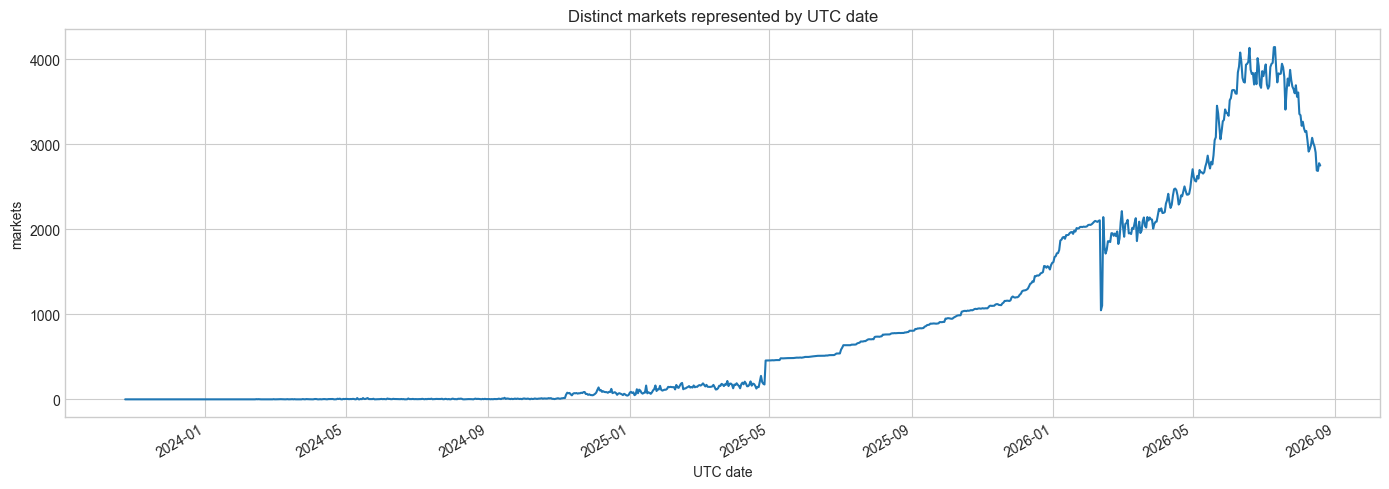

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
daily_summary.plot(
    x="date_utc",
    y="markets",
    ax=ax,
    color="tab:blue",
    title="Distinct markets represented by UTC date",
    legend=False,
)
ax.set_xlabel("UTC date")
ax.set_ylabel("markets")
plt.tight_layout()
plt.show()

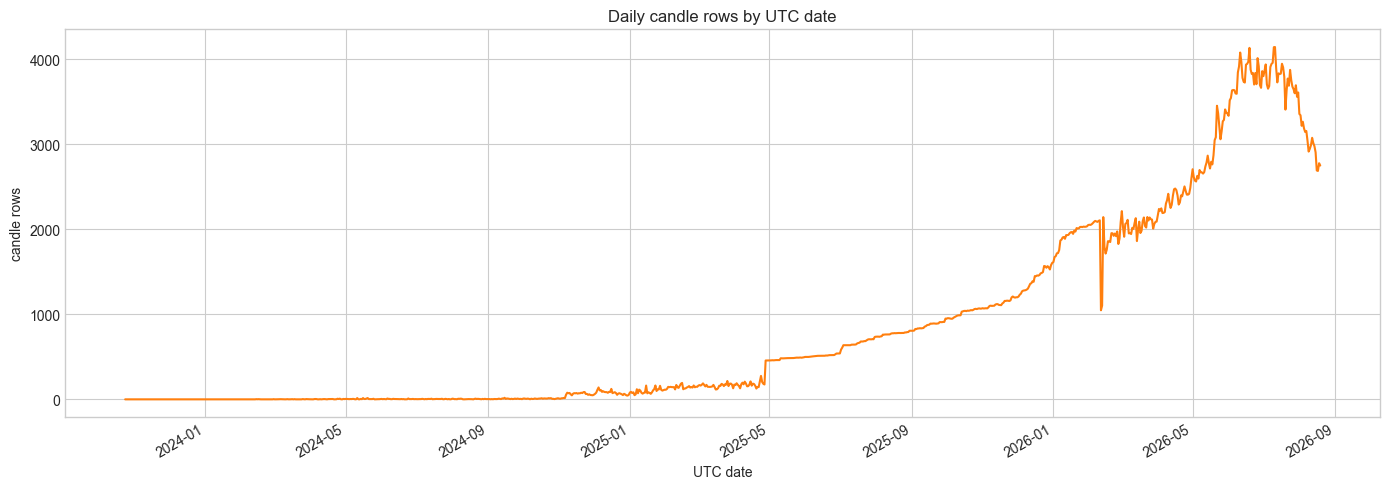

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
daily_summary.plot(
    x="date_utc",
    y="candle_rows",
    ax=ax,
    color="tab:orange",
    title="Daily candle rows by UTC date",
    legend=False,
)
ax.set_xlabel("UTC date")
ax.set_ylabel("candle rows")
plt.tight_layout()
plt.show()

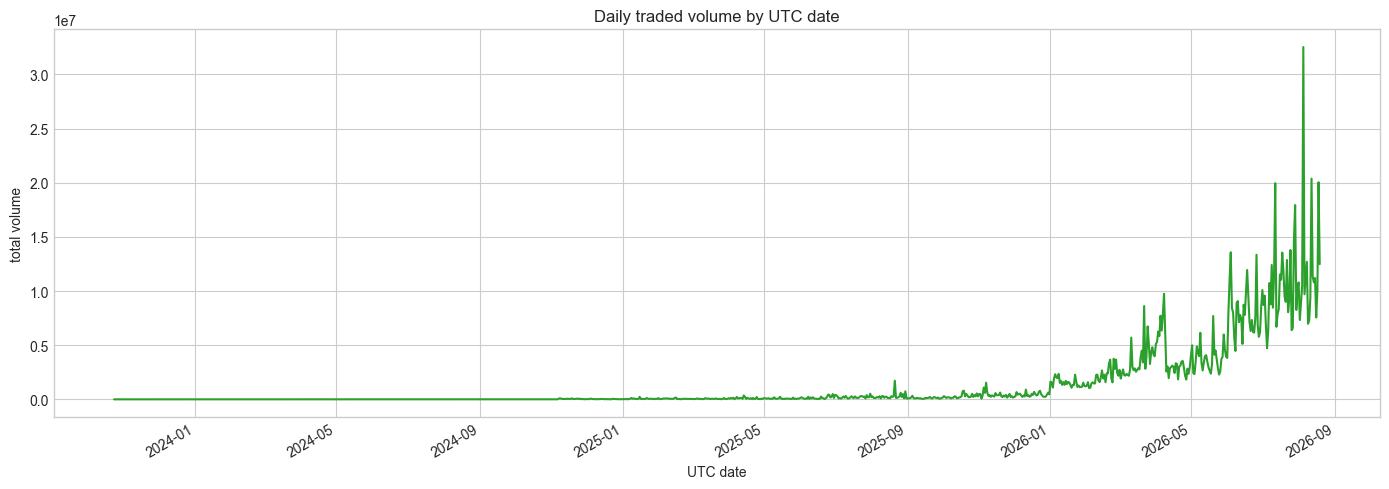

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

daily_summary.plot(
    x="date_utc",
    y="total_volume",
    ax=ax,
    color="tab:green",
    title="Daily traded volume by UTC date",
    legend=False,
)

ax.set_xlabel("UTC date")
ax.set_ylabel("total volume")
plt.tight_layout()
plt.show()

## 5. Market dates and question context

These checks connect coverage to actual market lifecycles and bring the question text back next to the quantitative data.

In [15]:
market_activity = (
    candles.groupby("market_id")
    .agg(
        observed_days=("date_utc", "nunique"),
        price_close_days=("price_close", "count"),
        total_volume=("volume", "sum"),
        first_candle=("date_utc", "min"),
        last_candle=("date_utc", "max"),
    )
    .reset_index()
)

question_context = (
    metadata.merge(market_activity, on="market_id", how="inner", validate="one_to_one")
    .sort_values(
        ["price_close_days", "total_volume"],
        ascending=False,
    )
    [[
        "market_id", "market_ticker", "market_question",
        "event_question", "series_title", "series_category",
        "open_time", "close_time", "first_candle", "last_candle",
        "observed_days", "price_close_days", "total_volume",
        "market_result",
    ]]
    .head(15)
)
display(question_context)

,market_id,market_ticker,market_question,event_question,series_title,series_category,open_time,close_time,first_candle,last_candle,observed_days,price_close_days,total_volume,market_result
4458,kalshi:KXPRESNOMD-28-GN,KXPRESNOMD-28-GN,Will Gavin Newsom be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,645,644,9117593.23,<NA>
4505,kalshi:KXPRESNOMR-28-JDV,KXPRESNOMR-28-JDV,Will J.D. Vance be the nominee for the Presidency for the Republican party?,2028 Republican presidential nominee,Republican Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,646,637,4080244.37,<NA>
4470,kalshi:KXPRESNOMD-28-JS,KXPRESNOMD-28-JS,Will Josh Shapiro be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,630,618,4624761.64,<NA>
2976,kalshi:KXIMPEACH-29-JAN20,KXIMPEACH-29-JAN20,"Will the President be impeached before Jan 20, 2029?",Will President Trump be impeached during his term?,President impeached,Politics,2024-11-08 15:00:00+00:00,2029-01-20 15:00:00+00:00,2024-11-09 00:00:00+00:00,2026-08-19 00:00:00+00:00,632,612,501680.94,<NA>
4448,kalshi:KXPRESNOMD-28-AOC,KXPRESNOMD-28-AOC,Will Alexandria Ocasio-Cortez be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,610,603,7965683.06,<NA>
4495,kalshi:KXPRESNOMR-28-DJT,KXPRESNOMR-28-DJT,Will Donald J. Trump be the nominee for the Presidency for the Republican party?,2028 Republican presidential nominee,Republican Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,626,602,3991303.50,<NA>
4480,kalshi:KXPRESNOMD-28-PB,KXPRESNOMD-28-PB,Will Pete Buttigieg be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,605,599,5559882.05,<NA>
2573,kalshi:KXGREENLAND-29,KXGREENLAND-29,Will Trump buy Greenland?,Will Trump buy at least part of Greenland?,Greenland purchase,Politics,2024-12-21 15:00:00+00:00,2029-01-20 15:00:00+00:00,2024-12-22 00:00:00+00:00,2026-08-19 00:00:00+00:00,604,599,3467499.78,<NA>
7276,kalshi:TESLAOPTIMUS-26DEC31,TESLAOPTIMUS-26DEC31,Tesla Optimus on sale before 2027?,Tesla Optimus released this year?,Tesla Optimus sale,Science and Technology,2024-02-09 14:30:00+00:00,2026-12-31 04:59:00+00:00,2024-02-10 00:00:00+00:00,2026-08-19 00:00:00+00:00,721,595,347637.24,<NA>
4473,kalshi:KXPRESNOMD-28-KH,KXPRESNOMD-28-KH,Will Kamala Harris be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,611,592,6760129.46,<NA>


## 6. Example probability paths

These examples use the raw daily closing probability. They are descriptive only; no outcome alignment or Brier Score is calculated here.

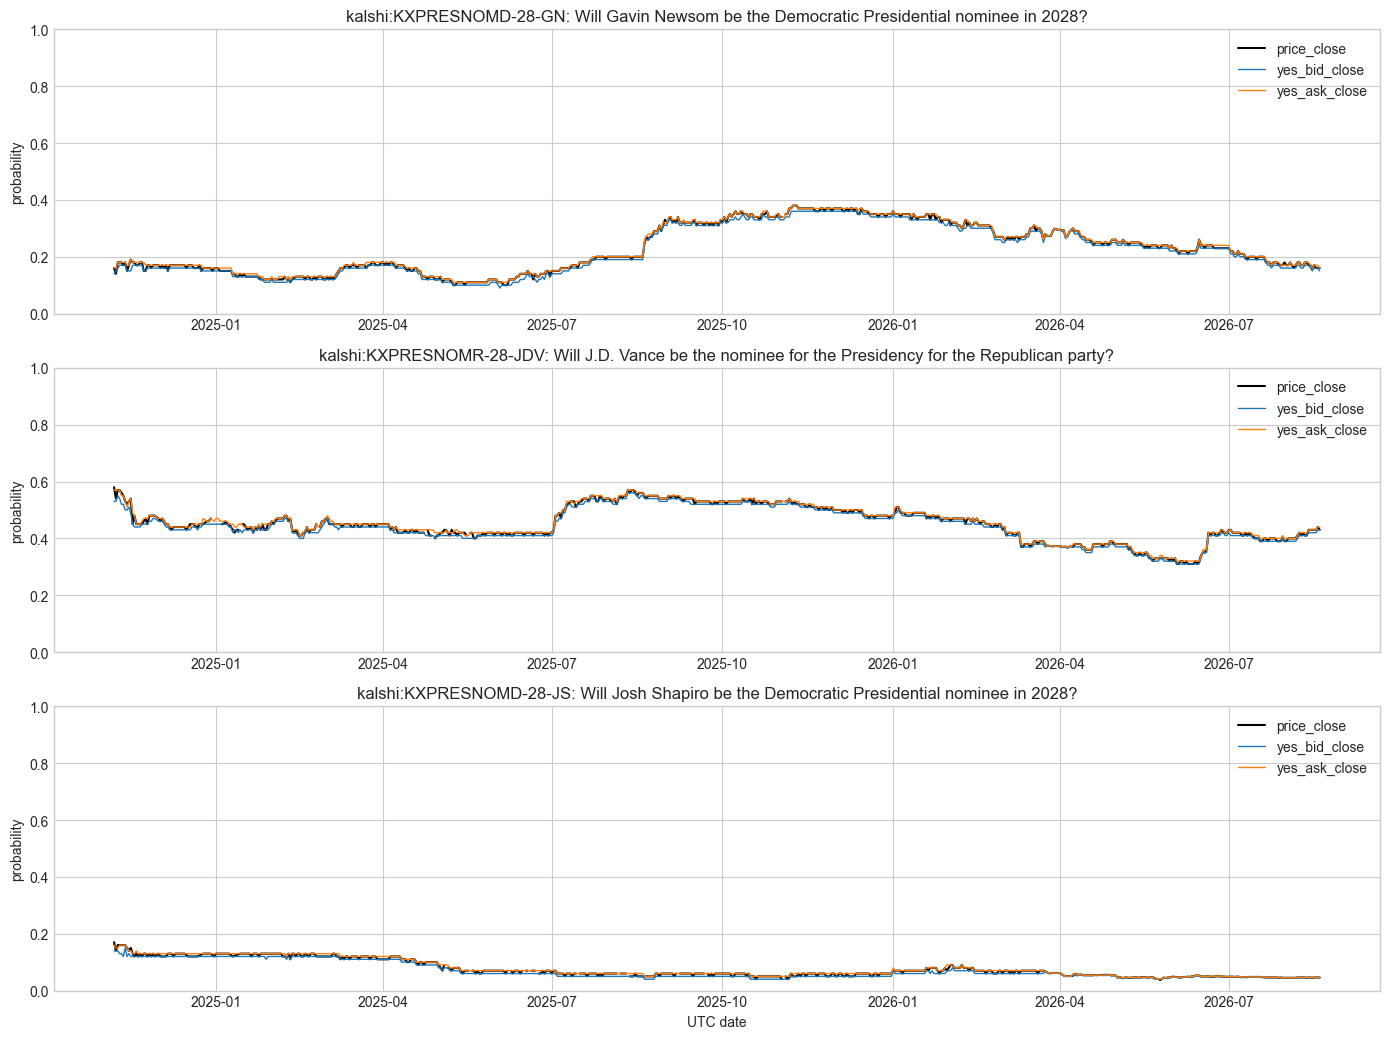

In [16]:
sample_ids = (
    market_activity.loc[market_activity["price_close_days"].gt(0)]
    .sort_values(
        ["price_close_days", "total_volume"],
        ascending=False,
    )
    .head(3)["market_id"]
    .tolist()
)

question_by_market = metadata.set_index("market_id")["market_question"].to_dict()
fig, axes = plt.subplots(
    len(sample_ids),
    1,
    figsize=(14, 3.5 * len(sample_ids)),
    squeeze=False,
)

for row_index, market_id in enumerate(sample_ids):
    sample = candles.loc[
        candles["market_id"].eq(market_id)
    ].sort_values("date_utc")
    axis = axes[row_index, 0]
    axis.plot(
        sample["date_utc"],
        sample["price_close"],
        color="black",
        linewidth=1.5,
        label="price_close",
    )
    axis.plot(
        sample["date_utc"],
        sample["yes_bid_close"],
        color="tab:blue",
        linewidth=1,
        label="yes_bid_close",
    )
    axis.plot(
        sample["date_utc"],
        sample["yes_ask_close"],
        color="tab:orange",
        linewidth=1,
        label="yes_ask_close",
    )
    axis.set_ylim(0, 1)
    axis.set_ylabel("probability")
    axis.set_title(
        f"{market_id}: {question_by_market.get(market_id) or 'question unavailable'}"
    )
    axis.legend(loc="best")

axes[-1, 0].set_xlabel("UTC date")
plt.tight_layout()
plt.show()

# Manual Examples

In [35]:
metadata.market_result.fillna('unknown').value_counts()

market_result
unknown    2956
no         2818
yes        1482
scalar       27
Name: count, dtype: int64[pyarrow]

In [47]:
resolved_metadata = metadata[metadata.market_result.isin(['yes', 'no'])].reset_index(drop=True)
main_metacols = ['market_id','market_question', 'volume_fp', 'lifetime_days', 'market_result']
resolved_metadata.loc[resolved_metadata.volume_fp.argsort().tail(50), main_metacols]

,market_id,market_question,volume_fp,lifetime_days,market_result
1897,kalshi:KXLIUSACOUPLE-26AUG31-KAZA,Will Kayda and Zach win Love Island USA Season 8?,1445607.33,39.485532,no
530,kalshi:KXCOLOMBIAPRES-26-AESP,Will Abelardo de la Espriella win the next Colombian presidential election?,1486022.39,282.124734,yes
3040,kalshi:KXSCRSENS-26-RFRY,Who will win the 2026 South Carolina Republican Senate special primary?,1502711.08,30.316979,no
3946,kalshi:KXVOTEPRIMARY-MAYORLA26SPRA-75,Will Spencer Pratt receive at least 50% of the popular vote in the first round of the 2026 Los Angeles mayoral elect...,1570112.24,35.928588,no
5,kalshi:KX14AMENDCASE-26-AUG,Will Trump's birthright citizenship order come into effect?,1591535.68,206.693137,no
2966,kalshi:KXRT-SPI-92,Spider-Man: Brand New Day Rotten Tomatoes score?,1623910.07,11.750000,no
2239,kalshi:KXMJSCHEDULE-26JUL,When will marijuana be rescheduled?,1634305.03,195.415972,no
2154,kalshi:KXMARRIAGESWIFTKELCE-26,Will Taylor Swift and Travis Kelce be married in 2026?,1645745.84,314.218715,yes
2219,kalshi:KXMI13D-26-DMCK,Will Donavan McKinney be the Democratic nominee for MI-13?,1647332.36,217.962627,yes
2220,kalshi:KXMI13D-26-STHA,Will Shri Thanedar be the Democratic nominee for MI-13?,1650232.06,217.962627,no


In [65]:
def plot_price_mean_for_market(market_id, figsize=(14, 5)):
    sub = candles.loc[candles["market_id"] == market_id].dropna(subset=["price_mean"]).merge(metadata, how="left", on="market_id")
    market_question = sub["market_question"].iloc[0] 
    series = sub.set_index("date_utc")["price_mean"].sort_index()
    fig, ax = plt.subplots(figsize=figsize)
    series.plot(ax=ax, title=f"{market_question} price_mean over time")
    ax.set_xlabel("UTC date")
    ax.set_ylabel("price_mean")
    plt.tight_layout()
    plt.show()
    return ax


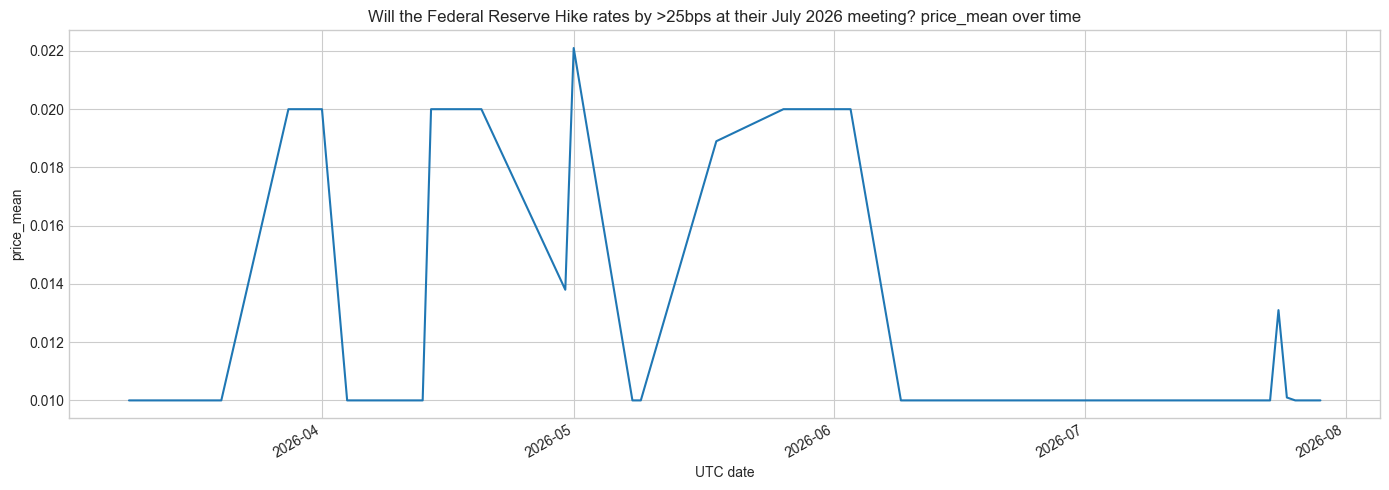

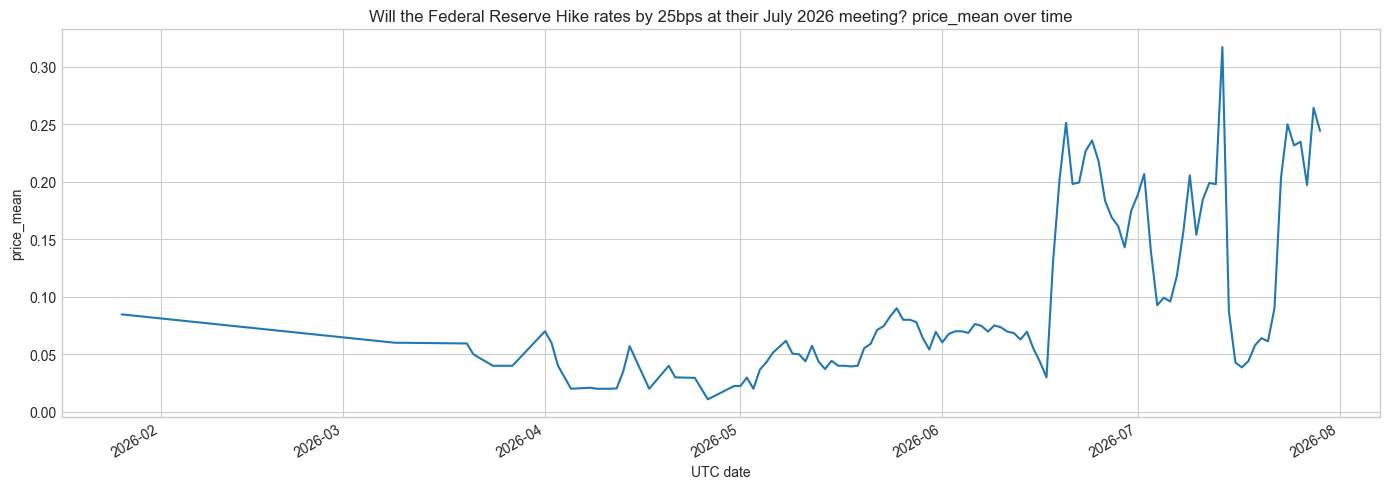

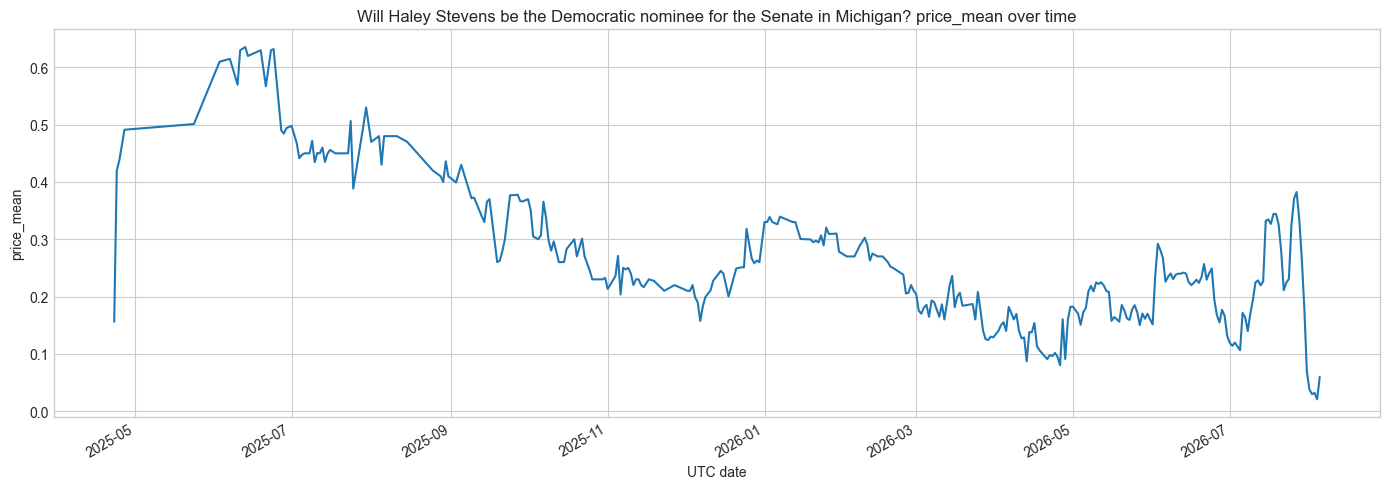

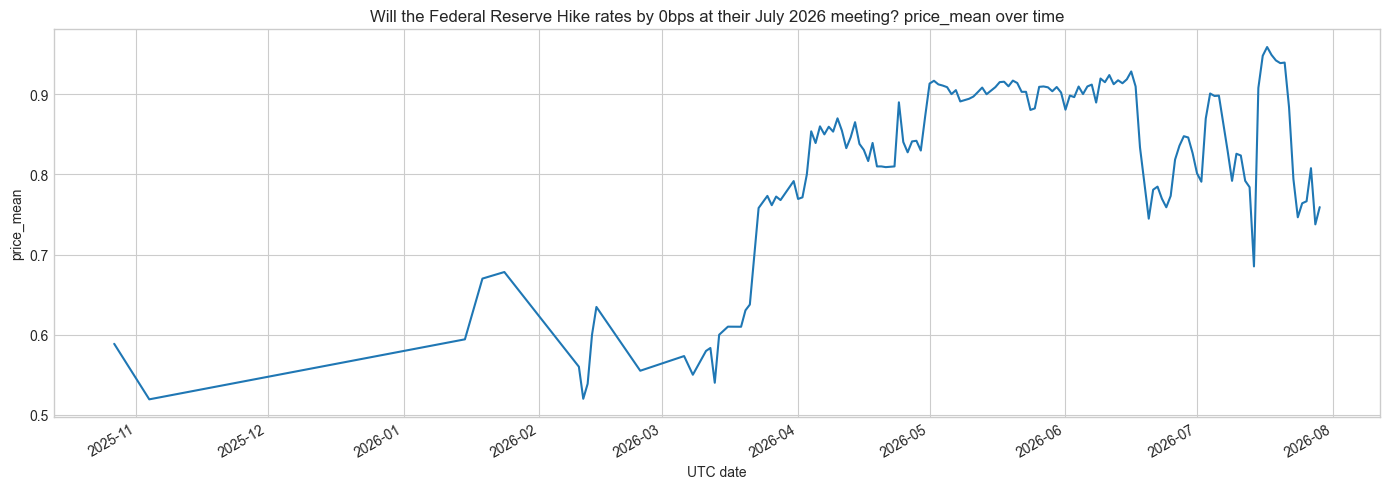

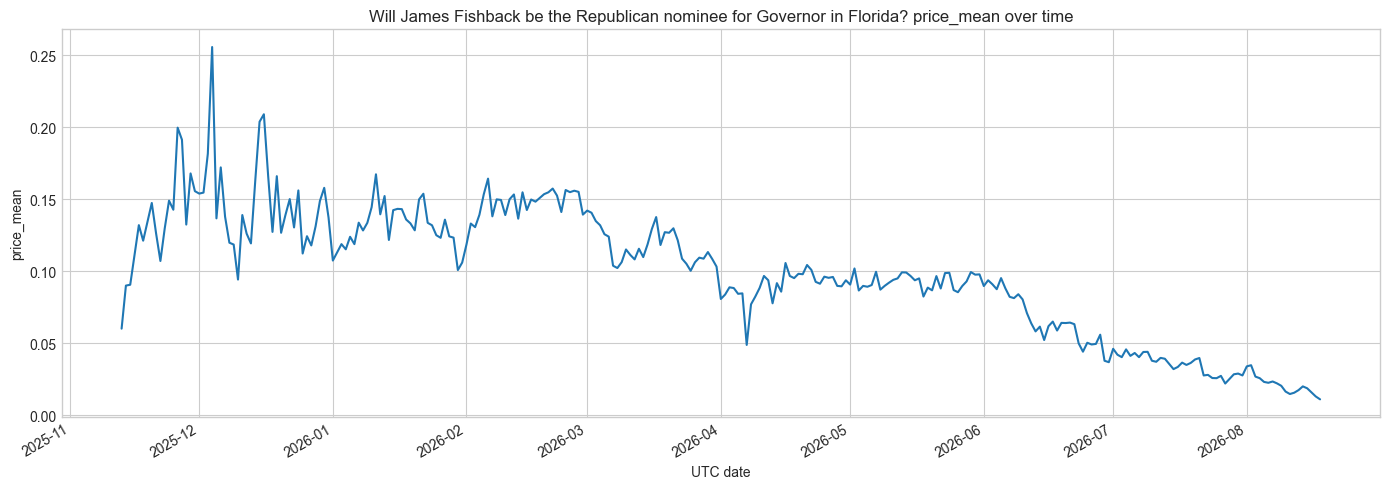

In [66]:
for market_id in resolved_metadata.loc[resolved_metadata.volume_fp.argsort().tail(5), "market_id"]:
    plot_price_mean_for_market(market_id)

## Top-volume market asset pack

The manual examples above show individual probability paths. Here we turn the 50 highest-volume resolved binary markets in the current snapshot into a compact case-study pack. Each market keeps its question, outcome, lifecycle, volume, and daily-observation profile in one row, while the corresponding candle rows remain available for plotting and later evaluation.

This is a descriptive asset pack: it prepares finished examples for inspection, but it does not yet choose a forecast horizon or report a final Brier Score.

In [ ]:
top50_metadata = (
    metadata.loc[metadata["market_result"].isin(["yes", "no"])]
    .sort_values(
        ["volume_fp", "market_id"],
        ascending=[False, True],
        na_position="last",
    )
    .head(50)
    .reset_index(drop=True)
    .copy()
)
top50_metadata.insert(0, "volume_rank", range(1, len(top50_metadata) + 1))
top50_market_ids = top50_metadata["market_id"].tolist()

top50_candles = candles.loc[candles["market_id"].isin(top50_market_ids)].copy()
top50_candles = top50_candles.sort_values(["market_id", "date_utc"])

quote_columns = ["yes_bid_close", "yes_ask_close"]
quote_pair_available = top50_candles[quote_columns].notna().all(axis=1)
top50_candles["quote_mid"] = top50_candles[quote_columns].mean(axis=1).where(
    quote_pair_available
)
top50_candles["quote_spread"] = (
    top50_candles["yes_ask_close"] - top50_candles["yes_bid_close"]
).where(quote_pair_available)

daily_profile = (
    top50_candles.groupby("market_id", as_index=False)
    .agg(
        candle_rows=("market_id", "size"),
        observed_days=("date_utc", "nunique"),
        price_close_days=("price_close", "count"),
        quote_mid_days=("quote_mid", "count"),
        total_daily_volume=("volume", "sum"),
        max_open_interest=("open_interest", "max"),
        mean_quote_spread=("quote_spread", "mean"),
        first_observation=("date_utc", "min"),
        last_observation=("date_utc", "max"),
        last_price_close=("price_close", "last"),
        last_quote_mid=("quote_mid", "last"),
    )
)

top50_assets = top50_metadata.merge(daily_profile, on="market_id", how="left")
top50_assets["outcome"] = top50_assets["market_result"].map({"yes": 1, "no": 0})
top50_assets["candle_coverage_pct"] = (
    100 * top50_assets["candle_rows"] / top50_assets["expected_daily_rows"]
).where(top50_assets["expected_daily_rows"].gt(0))
top50_assets["quote_coverage_pct"] = (
    100 * top50_assets["quote_mid_days"] / top50_assets["observed_days"]
).where(top50_assets["observed_days"].gt(0))

asset_columns = [
    "volume_rank", "market_id", "market_ticker", "market_question",
    "event_question", "series_title", "series_category", "market_result",
    "open_time", "close_time", "volume_fp", "lifetime_days",
    "candle_rows", "observed_days", "price_close_days", "quote_mid_days",
    "candle_coverage_pct", "quote_coverage_pct", "total_daily_volume",
    "max_open_interest", "mean_quote_spread", "last_price_close",
    "last_quote_mid", "first_observation", "last_observation",
]
display(top50_assets[asset_columns].round(3))

### Write the reusable case-study assets

The table above is the index: one finished row per selected market. The next cell writes that index and the matching daily rows as ordinary CSV files, together with a small JSON summary describing exactly how the pack was made.

In [ ]:
ASSET_DIR = DATA_DIR / "assets" / "top50_volume"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

asset_metadata_path = ASSET_DIR / "top50_market_assets.csv"
asset_candles_path = ASSET_DIR / "top50_daily_candles.csv"
asset_summary_path = ASSET_DIR / "top50_asset_summary.json"

top50_assets.to_csv(asset_metadata_path, index=False)

candle_columns = [
    "market_id", "market_ticker", "series_ticker", "end_period_ts",
    "date_utc", "price_open", "price_low", "price_high", "price_close",
    "price_mean", "price_previous", "yes_bid_close", "yes_ask_close",
    "volume", "open_interest",
]
top50_candles[candle_columns].to_csv(asset_candles_path, index=False)

def iso_or_none(value):
    return None if pd.isna(value) else pd.Timestamp(value).isoformat()

asset_summary = {
    "source_data_dir": str(DATA_DIR),
    "selection_rule": "resolved binary markets sorted by volume_fp descending",
    "requested_market_count": 50,
    "market_count": int(len(top50_assets)),
    "candle_row_count": int(len(top50_candles)),
    "market_result_counts": {
        str(key): int(value)
        for key, value in top50_assets["market_result"].value_counts(dropna=False).items()
    },
    "first_observation_utc": iso_or_none(top50_assets["first_observation"].min()),
    "last_observation_utc": iso_or_none(top50_assets["last_observation"].max()),
}
with asset_summary_path.open("w", encoding="utf-8") as handle:
    json.dump(asset_summary, handle, indent=2)

written_assets = pd.DataFrame(
    {
        "file": [
            asset_metadata_path.name,
            asset_candles_path.name,
            asset_summary_path.name,
        ],
        "rows_or_object": [len(top50_assets), len(top50_candles), "summary"],
        "path": [str(asset_metadata_path), str(asset_candles_path), str(asset_summary_path)],
    }
)
display(written_assets)

### Inspect one finished market asset

Change TOP50_RANK_TO_PLOT to inspect any market from the pack. The chart puts the question and resolved outcome next to the daily probability path, so the example can be read without opening the raw files.

In [ ]:
TOP50_RANK_TO_PLOT = 1

selected_asset = top50_assets.loc[
    top50_assets["volume_rank"] == TOP50_RANK_TO_PLOT
].iloc[0]
selected_candles = top50_candles.loc[
    top50_candles["market_id"] == selected_asset["market_id"]
].sort_values("date_utc")

question = str(selected_asset["market_question"])
question_for_title = question if len(question) <= 120 else question[:117] + "..."
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    selected_candles["date_utc"],
    selected_candles["price_mean"],
    marker="o",
    linewidth=2,
    label="price_mean",
)
ax.plot(
    selected_candles["date_utc"],
    selected_candles["price_close"],
    linestyle="--",
    alpha=0.75,
    label="price_close",
)

quote_rows = selected_candles.dropna(subset=quote_columns)
if not quote_rows.empty:
    ax.fill_between(
        quote_rows["date_utc"],
        quote_rows["yes_bid_close"],
        quote_rows["yes_ask_close"],
        alpha=0.18,
        label="bid-ask range",
    )

ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("UTC date")
ax.set_ylabel("Probability / quote")
ax.set_title(
    f"Rank {TOP50_RANK_TO_PLOT}: {question_for_title}\n"
    f"Outcome={selected_asset['market_result']} | volume={selected_asset['volume_fp']:,.0f} contracts"
)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
asset_plot_path = ASSET_DIR / f"top50_rank_{TOP50_RANK_TO_PLOT:02d}_market_path.png"
fig.savefig(asset_plot_path, dpi=150, bbox_inches="tight")
plt.show()

## A first predictive-quality check on the top-50 sample

The email asks for evidence about whether prediction-market prices aggregate useful beliefs. This small pilot turns the top-volume sample into an outcome-aligned evaluation: every market has a known yes/no result, and every forecast is taken from the latest available daily observation at least 1, 3, or 7 calendar days before resolution.

The results are deliberately descriptive. The top 50 are selected by activity, so they can illustrate a credible research workflow but cannot by themselves support a claim about all markets or all topic areas.

### What kinds of questions are represented?

Before scoring forecasts, we need to know what this high-volume sample actually contains. This table shows whether the top-50 examples cover several topic areas or are concentrated in only a few categories.

In [ ]:
top50_category_summary = (
    top50_assets.groupby("series_category", dropna=False, as_index=False)
    .agg(
        markets=("market_id", "nunique"),
        total_volume_contracts=("volume_fp", "sum"),
        median_lifetime_days=("lifetime_days", "median"),
        resolved_yes_rate=("outcome", "mean"),
        mean_observed_days=("observed_days", "mean"),
    )
    .sort_values("total_volume_contracts", ascending=False)
)
display(top50_category_summary.round(3))

### Define a simple forecast protocol

A Brier Score needs a probability, an outcome, and a clearly defined forecast time. Here the primary probability is price_mean; price_close is retained as a sensitivity check. For each horizon, we use the latest non-missing daily observation that is still at least that many calendar days before the market close.

In [ ]:
research_metadata_columns = [
    "market_id", "market_question", "event_question", "series_title",
    "series_category", "market_result", "volume_fp", "close_time", "outcome",
]
research_candles = top50_candles.merge(
    top50_assets[research_metadata_columns],
    on="market_id",
    how="inner",
)

forecast_rows = []
forecast_horizons = [1, 3, 7]
probability_fields = ["price_mean", "price_close"]

for probability_field in probability_fields:
    for horizon_days in forecast_horizons:
        eligible = research_candles.dropna(
            subset=[probability_field, "date_utc", "close_time", "outcome"]
        ).copy()
        forecast_cutoff = (
            eligible["close_time"].dt.normalize()
            - pd.Timedelta(days=horizon_days)
        )
        eligible = eligible.loc[eligible["date_utc"] <= forecast_cutoff]
        selected = (
            eligible.sort_values(["market_id", "date_utc"])
            .groupby("market_id", sort=False)
            .tail(1)
            .copy()
        )
        selected["probability_field"] = probability_field
        selected["horizon_days"] = horizon_days
        selected["forecast_date_utc"] = selected["date_utc"]
        selected["forecast_probability"] = selected[probability_field].clip(0, 1)
        selected["days_before_close"] = (
            selected["close_time"].dt.normalize()
            - selected["forecast_date_utc"]
        ).dt.days
        selected["squared_error"] = (
            selected["forecast_probability"] - selected["outcome"]
        ) ** 2
        selected["absolute_error"] = (
            selected["forecast_probability"] - selected["outcome"]
        ).abs()
        selected["forecast_correct"] = (
            selected["forecast_probability"] >= 0.5
        ) == (selected["outcome"] == 1)
        forecast_rows.append(
            selected[
                [
                    "market_id", "market_question", "event_question",
                    "series_title", "series_category", "market_result",
                    "volume_fp", "outcome", "probability_field", "horizon_days",
                    "forecast_date_utc", "days_before_close",
                    "forecast_probability", "squared_error", "absolute_error",
                    "forecast_correct",
                ]
            ]
        )

forecast_rows = pd.concat(forecast_rows, ignore_index=True)
primary_forecasts = forecast_rows.loc[
    (forecast_rows["probability_field"] == "price_mean")
    & (forecast_rows["horizon_days"] == 1)
].copy()


### Does the market beat simple probability baselines?

The Brier Score is mean-squared error for a binary probability forecast, so lower is better. The 0.5 baseline represents an uninformative coin flip; the sample-rate baseline uses the observed yes frequency in the same evaluated markets. A lower market score would be an initial sign that prices contain information about outcomes.

In [ ]:
brier_summary = (
    forecast_rows.groupby(["probability_field", "horizon_days"], as_index=False)
    .agg(
        forecast_markets=("market_id", "nunique"),
        brier_score=("squared_error", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        mean_probability=("forecast_probability", "mean"),
        realized_yes_rate=("outcome", "mean"),
        accuracy_at_half=("forecast_correct", "mean"),
        sharpness=("forecast_probability", lambda values: (values - 0.5).abs().mean()),
    )
)
brier_summary["market_coverage_pct"] = (
    100 * brier_summary["forecast_markets"] / len(top50_assets)
)
brier_summary["baseline_0_5_brier"] = 0.25
brier_summary["baseline_sample_rate_brier"] = (
    brier_summary["realized_yes_rate"]
    * (1 - brier_summary["realized_yes_rate"])
)
brier_summary["gain_vs_0_5"] = (
    brier_summary["baseline_0_5_brier"] - brier_summary["brier_score"]
)
brier_summary["gain_vs_sample_rate"] = (
    brier_summary["baseline_sample_rate_brier"]
    - brier_summary["brier_score"]
)
display(brier_summary.round(4))

### Does performance look different across topic areas?

This is the first direct comparison across categories. Small groups should be treated as exploratory only; the table reports their sample size alongside the score so that an apparent difference is not mistaken for strong evidence.

In [ ]:
category_forecast_summary = (
    primary_forecasts.groupby("series_category", dropna=False, as_index=False)
    .agg(
        forecast_markets_1d=("market_id", "nunique"),
        brier_score_1d=("squared_error", "mean"),
        baseline_0_5_brier_1d=("outcome", lambda values: ((0.5 - values) ** 2).mean()),
        mean_probability_1d=("forecast_probability", "mean"),
        accuracy_at_half_1d=("forecast_correct", "mean"),
    )
)
category_summary = top50_category_summary.merge(
    category_forecast_summary,
    on="series_category",
    how="left",
)
category_summary["forecast_coverage_pct_1d"] = (
    100 * category_summary["forecast_markets_1d"] / category_summary["markets"]
)
category_summary["gain_vs_0_5_1d"] = (
    category_summary["baseline_0_5_brier_1d"]
    - category_summary["brier_score_1d"]
)
display(category_summary.round(4))

### Are the probabilities calibrated?

Calibration asks whether markets assigned probabilities that match observed frequencies. For example, markets grouped around 70% should resolve yes roughly 70% of the time. This is a different question from ranking markets correctly and speaks directly to the idea of belief aggregation.

In [ ]:
calibration_bins = [-0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.001]
calibration_labels = [
    "0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
    "50-60%", "60-70%", "70-80%", "80-90%", "90-100%",
]
calibration_input = primary_forecasts.copy()
calibration_input["probability_bin"] = pd.cut(
    calibration_input["forecast_probability"],
    bins=calibration_bins,
    labels=calibration_labels,
    include_lowest=True,
)
calibration_summary = (
    calibration_input.groupby("probability_bin", observed=False, as_index=False)
    .agg(
        forecast_markets=("market_id", "nunique"),
        mean_forecast=("forecast_probability", "mean"),
        observed_yes_rate=("outcome", "mean"),
        brier_score=("squared_error", "mean"),
    )
)
display(calibration_summary.round(4))

In [ ]:
calibration_plot_data = calibration_summary.dropna(
    subset=["mean_forecast", "observed_yes_rate"]
)
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
ax.scatter(
    calibration_plot_data["mean_forecast"],
    calibration_plot_data["observed_yes_rate"],
    s=calibration_plot_data["forecast_markets"] * 18,
    alpha=0.8,
)
for _, row in calibration_plot_data.iterrows():
    ax.annotate(
        row["probability_bin"],
        (row["mean_forecast"], row["observed_yes_rate"]),
        xytext=(4, 4),
        textcoords="offset points",
    )
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean forecast probability")
ax.set_ylabel("Observed yes rate")
ax.set_title("Top-50 calibration: price_mean one day before close")
ax.legend()
plt.tight_layout()
calibration_plot_path = ASSET_DIR / "top50_calibration_price_mean_1d.png"
fig.savefig(calibration_plot_path, dpi=150, bbox_inches="tight")
plt.show()

### Market-level case-study table

This is the compact handoff table for the first discussion: one row per high-volume market, with its question, category, resolved outcome, one-day-ahead probability, and forecast error. It makes it possible to inspect individual successes and failures behind the aggregate score.

In [ ]:
top50_case_study = primary_forecasts.merge(
    top50_assets[["market_id", "volume_rank", "lifetime_days", "observed_days"]],
    on="market_id",
    how="left",
)
case_study_columns = [
    "volume_rank", "market_id", "market_question", "series_category",
    "volume_fp", "lifetime_days", "observed_days", "market_result",
    "forecast_date_utc", "days_before_close", "forecast_probability",
    "outcome", "squared_error", "absolute_error", "forecast_correct",
]
display(
    top50_case_study.sort_values("volume_rank")[case_study_columns].round(4)
)

### Save the research-ready analysis outputs

The descriptive tables and the calibration figure are saved next to the top-50 asset pack. This leaves a small, reproducible bundle that can be shown to a supervisor and later extended with more markets or historical data.

In [ ]:
analysis_paths = {
    "forecast_rows": ASSET_DIR / "top50_forecast_rows.csv",
    "brier_scores": ASSET_DIR / "top50_brier_scores.csv",
    "category_summary": ASSET_DIR / "top50_category_summary.csv",
    "calibration": ASSET_DIR / "top50_calibration.csv",
    "case_study": ASSET_DIR / "top50_case_study.csv",
    "analysis_summary": ASSET_DIR / "top50_analysis_summary.json",
}

forecast_rows.to_csv(analysis_paths["forecast_rows"], index=False)
brier_summary.to_csv(analysis_paths["brier_scores"], index=False)
category_summary.to_csv(analysis_paths["category_summary"], index=False)
calibration_summary.to_csv(analysis_paths["calibration"], index=False)
top50_case_study.to_csv(analysis_paths["case_study"], index=False)

analysis_summary = {
    "sample": "50 highest-volume resolved binary markets",
    "primary_probability_field": "price_mean",
    "sensitivity_probability_field": "price_close",
    "forecast_horizons_days": forecast_horizons,
    "forecast_definition": "latest available observation on or before close date minus horizon",
    "primary_metric": "Brier Score; lower is better",
    "baseline_metrics": ["constant 0.5", "evaluated-sample yes rate"],
    "interpretation": "descriptive pilot; top-volume selection is not representative of all markets",
}
with analysis_paths["analysis_summary"].open("w", encoding="utf-8") as handle:
    json.dump(analysis_summary, handle, indent=2)

analysis_file_index = pd.DataFrame(
    {
        "file": [path.name for path in analysis_paths.values()],
        "path": [str(path) for path in analysis_paths.values()],
    }
)
analysis_file_index.loc[len(analysis_file_index)] = {
    "file": calibration_plot_path.name,
    "path": str(calibration_plot_path),
}
display(analysis_file_index)

## Research takeaway

The first top-50 sample already gives us a useful preliminary answer: the most active resolved markets are not behaving like random coin flips. Their daily probabilities are substantially closer to the final outcomes than a constant 50% forecast, especially when measured close to resolution. This is consistent with the idea that prediction-market prices aggregate information and beliefs rather than representing activity alone.

The result is not yet a general claim about prediction markets. The sample was selected by volume, the number of markets is small, and the topic mix is uneven. The category differences and the calibration plot are therefore best read as research leads: some areas may be easier to predict, while others may need more observations or a different forecast horizon.

The next step is to keep this evaluation protocol fixed and expand the sample beyond the top 50. We should score all eligible resolved markets, report uncertainty around each Brier Score, compare categories with sufficient sample sizes, and use a time-based holdout for a genuinely out-of-sample result. That would turn this demonstration into evidence about where prediction markets are informative and where their forecasts are less reliable.